# Breast Cancer Survival Prediction (Binary Classification)

**Dataset:** Breast Cancer Dataset — clinical and demographic features of breast cancer patients  
**Domain:** Healthcare  
**Task:** Supervised Binary Classification  

**Classes:**
-  → Alive  
-  → Dead  

**Primary metric:** Macro F1  
**Secondary metrics:** Accuracy, Precision, Recall, ROC-AUC  

---

## Problem Definition

Breast cancer is one of the most common cancers worldwide. Predicting patient survival outcome
from clinical features at diagnosis can help clinicians identify high-risk patients early and
prioritise care pathways. This is a **binary classification** task: given tumour characteristics,
staging information, and patient demographics, predict whether the patient is Alive or Dead
at the end of the follow-up period.

**Success criteria:**  
- Primary: **Macro F1** — balanced performance across both classes, accounting for class imbalance.  
- Secondary: ROC-AUC, Precision, Recall, and Accuracy for a complete picture.

> **Why not accuracy alone?** The dataset is imbalanced (~85% Alive, ~15% Dead).
> A naive model that always predicts Alive achieves 85% accuracy but zero recall on the minority class.
> Macro F1 penalises this behaviour and better reflects real clinical utility.

In [10]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## 1. Exploratory Data Analysis (EDA)

We examine the dataset structure, feature types, class balance, and distributions
to justify every preprocessing and modelling decision that follows.

In [11]:
df = pd.read_csv("Breast_Cancer.csv")

# Strip whitespace from column names and string values
df.columns = df.columns.str.strip()
df["Grade"]          = df["Grade"].astype(str).str.strip().replace("anaplastic; Grade IV", "4")
df["Marital Status"] = df["Marital Status"].astype(str).str.strip()

print(f"Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Target classes: {df['Status'].unique().tolist()}")
df.head()

Shape : 4024 rows x 16 columns
Target classes: ['Alive', 'Dead']


,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [12]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     4024 non-null   int64 
 1   Race                    4024 non-null   object
 2   Marital Status          4024 non-null   object
 3   T Stage                 4024 non-null   object
 4   N Stage                 4024 non-null   object
 5   6th Stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   Grade                   4024 non-null   object
 8   A Stage                 4024 non-null   object
 9   Tumor Size              4024 non-null   int64 
 10  Estrogen Status         4024 non-null   object
 11  Progesterone Status     4024 non-null   object
 12  Regional Node Examined  4024 non-null   int64 
 13  Reginol Node Positive   4024 non-null   int64 
 14  Survival Months         4024 non-null   int64 
 15  Stat

### 1.1 Class Distribution

Understanding class balance is critical before choosing metrics and models.

Status
Alive    3408
Dead      616
Name: count, dtype: int64

Imbalance ratio: 5.5:1


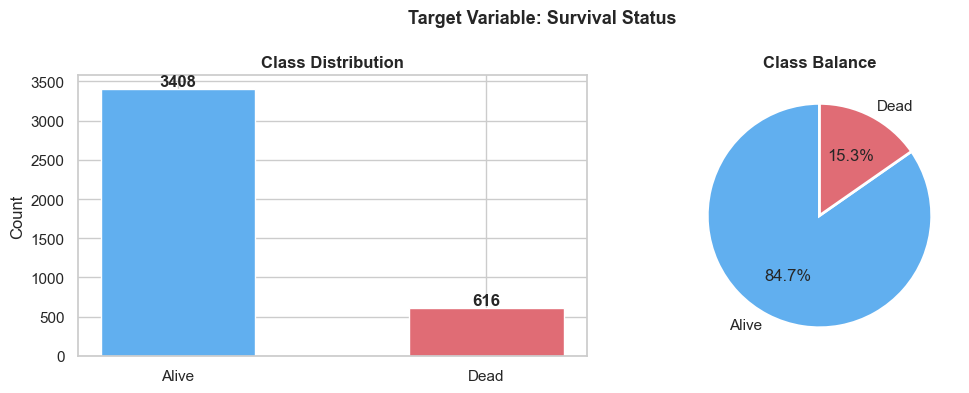

In [13]:
class_counts = df["Status"].value_counts()
print(class_counts)
print(f"\nImbalance ratio: {class_counts[0]/class_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(class_counts.index, class_counts.values,
            color=["#61AFEF","#E06C75"], edgecolor="white", width=0.5)
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontweight="bold")

axes[1].pie(class_counts.values, labels=class_counts.index,
            colors=["#61AFEF","#E06C75"],
            autopct="%1.1f%%", startangle=90,
            wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class Balance", fontweight="bold")

plt.suptitle("Target Variable: Survival Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.2 Numeric Feature Distributions

We examine the five numeric features across both survival classes.

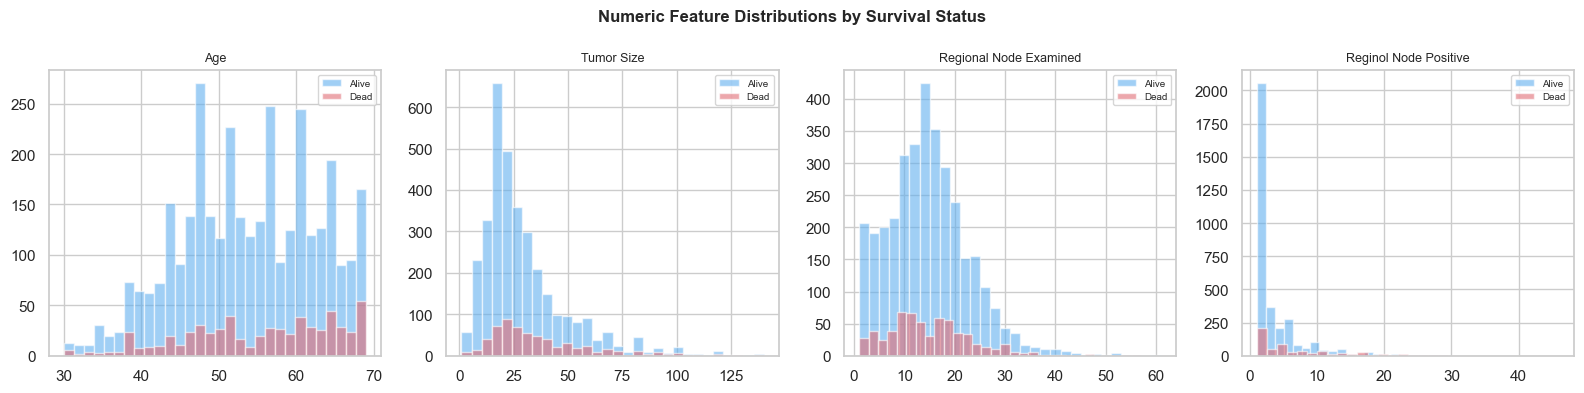

In [14]:
numeric_cols = ["Age", "Tumor Size", "Regional Node Examined", "Reginol Node Positive"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numeric_cols):
    for status, color in zip(["Alive", "Dead"], ["#61AFEF", "#E06C75"]):
        ax.hist(df[df["Status"] == status][col], bins=30,
                alpha=0.6, label=status, color=color, edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

plt.suptitle("Numeric Feature Distributions by Survival Status", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 1.3 Key Categorical Feature Analysis

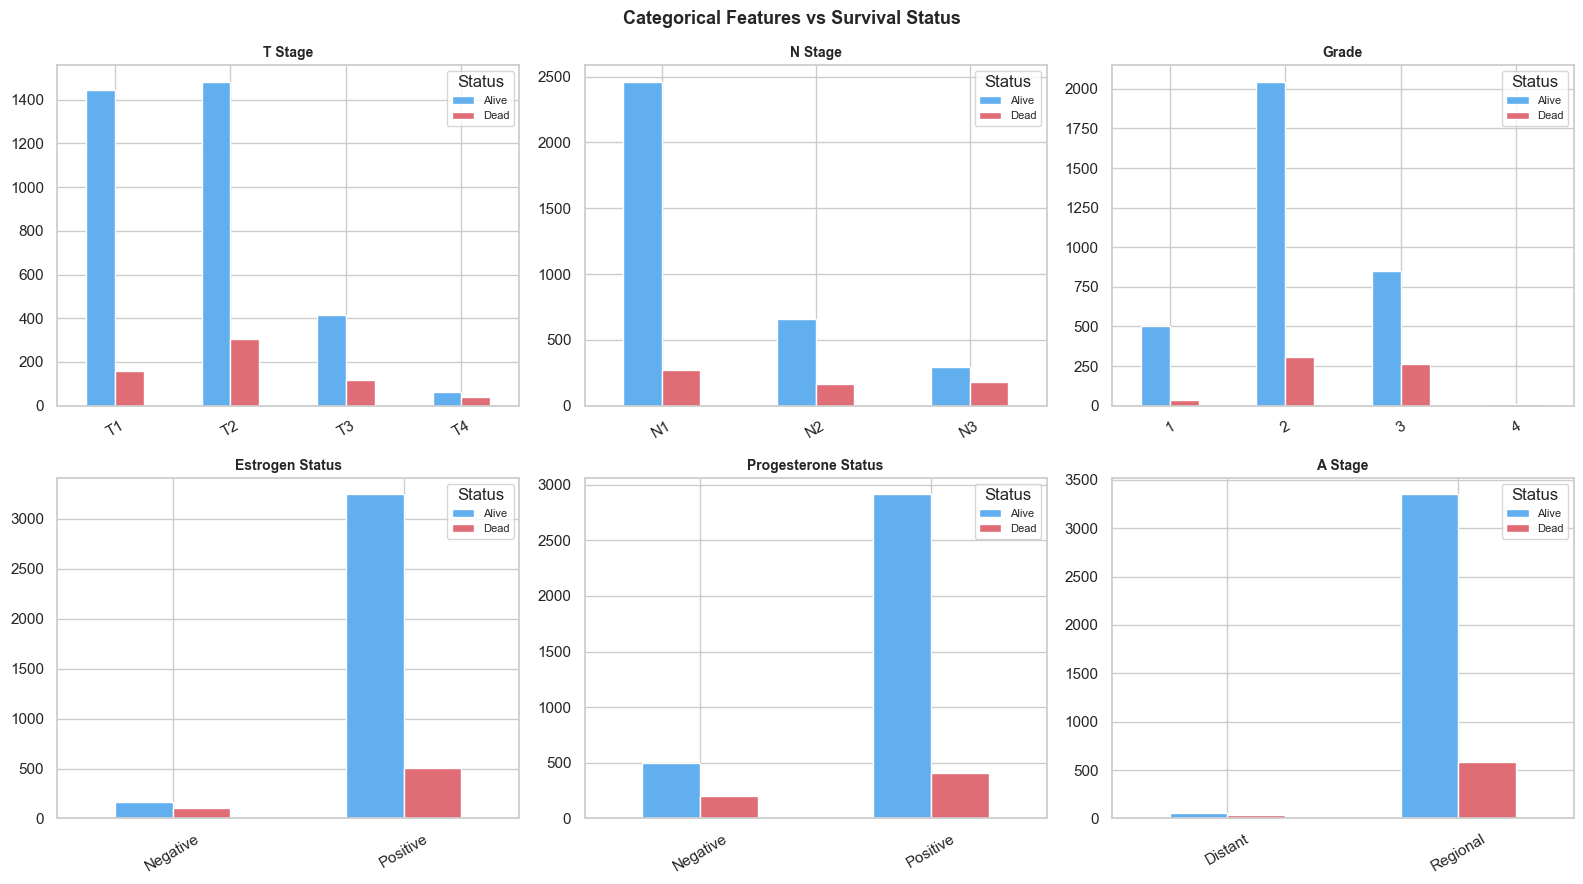

In [15]:
cat_plot_cols = ["T Stage", "N Stage", "Grade", "Estrogen Status",
                 "Progesterone Status", "A Stage"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes, cat_plot_cols):
    ct = df.groupby([col, "Status"]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=ax, color=["#61AFEF","#E06C75"],
            edgecolor="white", rot=30)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.legend(title="Status", fontsize=8)

plt.suptitle("Categorical Features vs Survival Status", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

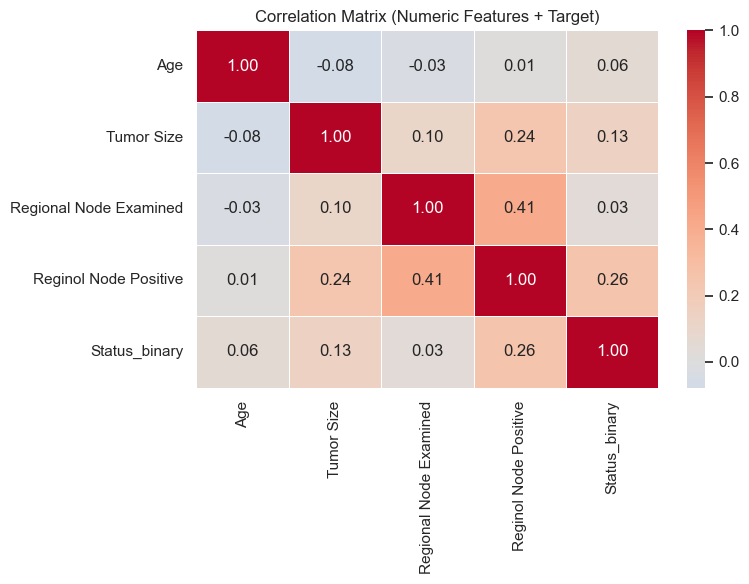

In [16]:
numeric_df = df[["Age","Tumor Size","Regional Node Examined","Reginol Node Positive"]].copy()
numeric_df["Status_binary"] = (df["Status"] == "Dead").astype(int)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Correlation Matrix (Numeric Features + Target)", fontsize=12)
plt.tight_layout()
plt.show()

---
## 2. Preprocessing

**Steps and justifications:**

1. **Drop ** — This column is a proxy for the target:
   patients who die have a lower survival time by definition (mean 45.6 months Dead vs 75.9 Alive).
   Including it would constitute **data leakage** — the model would learn the target from itself.

2. **One-hot encode all nominal categoricals** — Unlike label encoding (which assigns arbitrary
   ordinal integers), one-hot encoding makes no assumption about order between categories
   such as Race or Marital Status.

3. **Stratified 80/20 split** — Preserves the class imbalance ratio in both train and test sets.

4. **StandardScaler** — Fit on training data only, then applied to test data, preventing
   information from the test set from influencing the scaler parameters.

In [17]:
# Step 1: drop leaky column
df_model = df.drop(columns=["Survival Months"]).copy()

# Step 2: one-hot encode all nominal categorical features
cat_cols = ["Race", "Marital Status", "T Stage", "N Stage", "6th Stage",
            "differentiate", "Grade", "A Stage", "Estrogen Status", "Progesterone Status"]

df_enc = pd.get_dummies(df_model, columns=cat_cols, drop_first=False)

# Convert bool dummies to int (0/1)
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

# Encode target: Dead=1, Alive=0
df_enc["Status"] = (df_enc["Status"] == "Dead").astype(int)

print(f"Features after encoding : {df_enc.shape[1] - 1}")
print(f"Original shape          : {df.shape[1] - 1} features")
print(f"Encoded column sample   : {df_enc.columns.tolist()[:8]}")

Features after encoding : 38
Original shape          : 15 features
Encoded column sample   : ['Age', 'Tumor Size', 'Regional Node Examined', 'Reginol Node Positive', 'Status', 'Race_Black', 'Race_Other', 'Race_White']


In [18]:
X = df_enc.drop(columns=["Status"]).astype(float)
y = df_enc["Status"].values
feature_columns = X.columns.tolist()

# Stratified split preserves class proportions
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X.values, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

# Scale: fit ONLY on train, transform both
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train shape : {X_train.shape}")
print(f"Test shape  : {X_test.shape}")
print(f"Train class distribution (Alive / Dead) : {np.bincount(y_train)}")
print(f"Test class distribution  (Alive / Dead) : {np.bincount(y_test)}")

Train shape : (3219, 38)
Test shape  : (805, 38)
Train class distribution (Alive / Dead) : [2726  493]
Test class distribution  (Alive / Dead) : [682 123]


---
## 3. Model Training

We train three models with **genuinely distinct architectures and algorithmic principles**:

| Model | Family | Key idea |
|---|---|---|
| **Logistic Regression** | Linear | Finds a linear decision boundary by optimising log-likelihood |
| **Random Forest** | Ensemble / Tree-based | Aggregates many decision trees built on random feature subsets |
| **K-Nearest Neighbours** | Instance-based | Classifies by majority vote of k closest training points |

All three use the same train/test split and the same scaled features for a **fair comparison**.

> **Class imbalance strategy:**  is applied to Logistic Regression
> and Random Forest. This weights each class inversely proportional to its frequency,
> ensuring the minority class (Dead, ~15%) is not ignored during training.

In [19]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest (Baseline)": RandomForestClassifier(
        n_estimators=100, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier()
}

predictions   = {}
probabilities = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name]    = model.predict(X_test)
    probabilities[name]  = model.predict_proba(X_test)[:, 1]

print("Baseline models trained.")

Baseline models trained.


### 3.1 Hyperparameter Tuning (GridSearchCV)

We tune **all three models** using 5-fold stratified cross-validation scored on Macro F1.
Tuning all models under the same conditions ensures a **fair comparison**.

- **Logistic Regression:** regularisation strength , penalty type, solver
- **Random Forest:** number of trees, max depth, min samples to split
- **KNN:** number of neighbours, distance metric, weighting scheme

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- Logistic Regression ---
lr_param_grid = {
    "C"      : [0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver" : ["liblinear"]
}
lr_grid = GridSearchCV(
    estimator=LogisticRegression(class_weight="balanced", max_iter=2000,
                                  random_state=RANDOM_STATE),
    param_grid=lr_param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1
)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_
predictions["Logistic Regression (Tuned)"]   = best_lr.predict(X_test)
probabilities["Logistic Regression (Tuned)"] = best_lr.predict_proba(X_test)[:, 1]
trained_models["Logistic Regression (Tuned)"] = best_lr
print("Best LR params  :", lr_grid.best_params_)
print("Best CV F1-macro:", round(lr_grid.best_score_, 4))

Best LR params  : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-macro: 0.6146


In [21]:
# --- Random Forest ---
rf_param_grid = {
    "n_estimators"  : [100, 200],
    "max_depth"      : [None, 10, 20],
    "min_samples_split": [2, 5]
}
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_grid=rf_param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_
predictions["Random Forest (Tuned)"]   = best_rf.predict(X_test)
probabilities["Random Forest (Tuned)"] = best_rf.predict_proba(X_test)[:, 1]
trained_models["Random Forest (Tuned)"] = best_rf
print("Best RF params  :", rf_grid.best_params_)
print("Best CV F1-macro:", round(rf_grid.best_score_, 4))

Best RF params  : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1-macro: 0.6224


In [22]:
# --- KNN ---
knn_param_grid = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights"    : ["uniform", "distance"],
    "metric"     : ["euclidean", "manhattan"]
}
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid, cv=cv,
    scoring="f1_macro", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_knn = knn_grid.best_estimator_
predictions["KNN (Tuned)"]   = best_knn.predict(X_test)
probabilities["KNN (Tuned)"] = best_knn.predict_proba(X_test)[:, 1]
trained_models["KNN (Tuned)"] = best_knn
print("Best KNN params  :", knn_grid.best_params_)
print("Best CV F1-macro :", round(knn_grid.best_score_, 4))

Best KNN params  : {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV F1-macro : 0.5907


---
## 4. Evaluation and Comparison

For each model we compute:
- **Accuracy** — overall correct predictions (note: misleading alone with imbalanced data)
- **Precision (Macro)** — average precision across both classes
- **Recall (Macro)** — average recall; high recall on the Dead class means fewer missed fatalities
- **F1-score (Macro)** — harmonic mean of precision and recall, primary metric
- **ROC-AUC** — area under the ROC curve; measures ranking quality of probability predictions

We compare tuned versions of all three models alongside their baselines.

In [23]:
metrics_rows = []
CLASS_NAMES  = ["Alive", "Dead"]

for model_name, y_pred in predictions.items():
    row = {
        "Model"           : model_name,
        "Accuracy"        : accuracy_score(y_test, y_pred),
        "Precision-Macro" : precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall-Macro"    : recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Macro"        : f1_score(y_test, y_pred, average="macro", zero_division=0),
        "ROC-AUC"         : roc_auc_score(y_test, probabilities[model_name])
    }
    metrics_rows.append(row)

comparison_df = (pd.DataFrame(metrics_rows)
                 .sort_values("F1-Macro", ascending=False)
                 .reset_index(drop=True))

display(comparison_df.style.format({
    "Accuracy"        : "{:.4f}",
    "Precision-Macro" : "{:.4f}",
    "Recall-Macro"    : "{:.4f}",
    "F1-Macro"        : "{:.4f}",
    "ROC-AUC"         : "{:.4f}"
}).highlight_max(subset=["F1-Macro","ROC-AUC","Recall-Macro"], color="#c6f0c2")
 .highlight_min(subset=["F1-Macro","ROC-AUC"], color="#f0c2c2"))

,Model,Accuracy,Precision-Macro,Recall-Macro,F1-Macro,ROC-AUC
0,Random Forest (Tuned),0.7938,0.5977,0.5951,0.5964,0.6965
1,Logistic Regression,0.6981,0.5956,0.6652,0.5924,0.7266
2,Logistic Regression (Tuned),0.6981,0.5956,0.6652,0.5924,0.7267
3,KNN,0.8360,0.6382,0.5634,0.5747,0.6332
4,KNN (Tuned),0.8112,0.5784,0.5487,0.5546,0.6127
5,Random Forest (Baseline),0.8348,0.5994,0.5293,0.5253,0.6742


In [24]:
# Print full classification report for each model
for model_name in comparison_df["Model"]:
    print("=" * 70)
    print(f"Classification Report: {model_name}")
    print(classification_report(y_test, predictions[model_name],
                                target_names=CLASS_NAMES, zero_division=0))

Classification Report: Random Forest (Tuned)
              precision    recall  f1-score   support

       Alive       0.88      0.88      0.88       682
        Dead       0.32      0.31      0.31       123

    accuracy                           0.79       805
   macro avg       0.60      0.60      0.60       805
weighted avg       0.79      0.79      0.79       805

Classification Report: Logistic Regression
              precision    recall  f1-score   support

       Alive       0.91      0.71      0.80       682
        Dead       0.28      0.62      0.38       123

    accuracy                           0.70       805
   macro avg       0.60      0.67      0.59       805
weighted avg       0.82      0.70      0.74       805

Classification Report: Logistic Regression (Tuned)
              precision    recall  f1-score   support

       Alive       0.91      0.71      0.80       682
        Dead       0.28      0.62      0.38       123

    accuracy                           0.70

### 4.1 Confusion Matrices

Confusion matrices show the raw counts of true positives (TP), false positives (FP),
true negatives (TN), and false negatives (FN). In a clinical context, **False Negatives
(predicting Alive when the patient is Dead) are the most costly error**, as they miss
patients who need intervention.

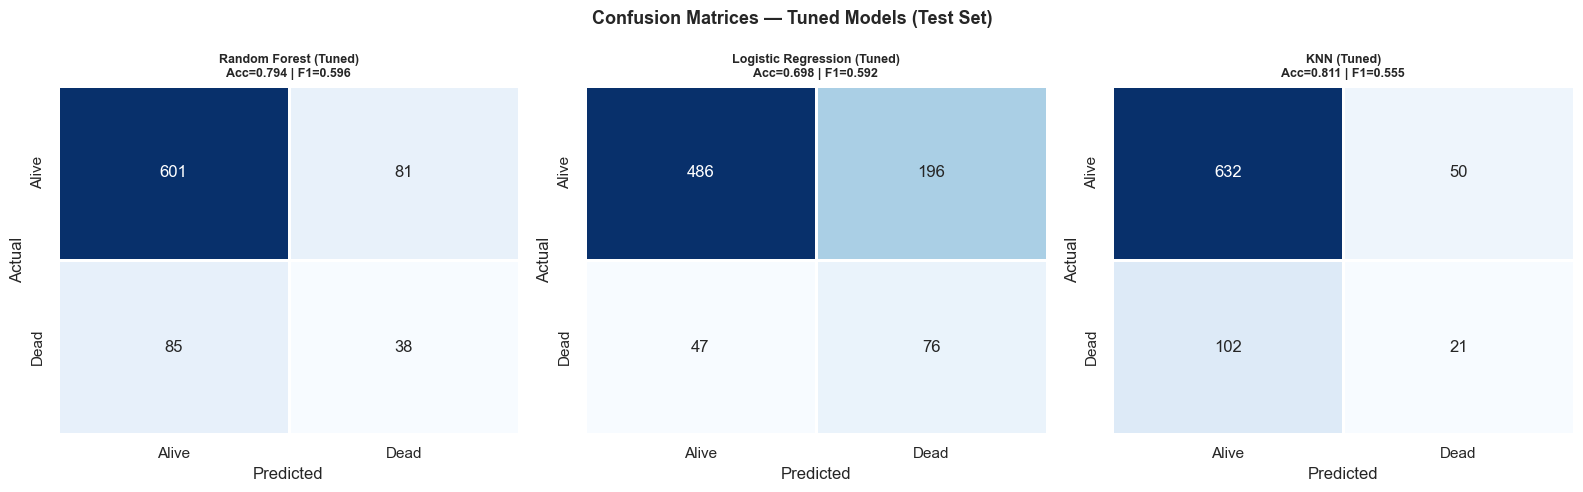

In [25]:
tuned_models = [m for m in comparison_df["Model"] if "Tuned" in m]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model_name in zip(axes, tuned_models):
    cm = confusion_matrix(y_test, predictions[model_name])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
                linewidths=1, linecolor="white")
    acc = accuracy_score(y_test, predictions[model_name])
    f1  = f1_score(y_test, predictions[model_name], average="macro", zero_division=0)
    ax.set_title(f"{model_name}\nAcc={acc:.3f} | F1={f1:.3f}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrices — Tuned Models (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 ROC Curves

ROC curves plot the True Positive Rate (Recall) against the False Positive Rate
across all classification thresholds. A model that hugs the top-left corner has
high discriminative power. AUC = 0.5 is random; AUC = 1.0 is perfect.

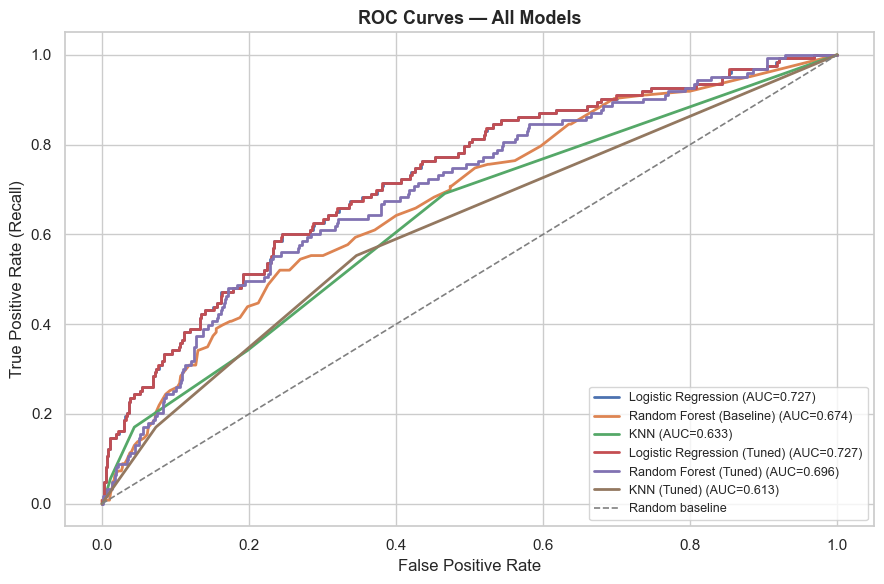

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B2","#937860"]

for (model_name, probs), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    model_auc   = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{model_name} (AUC={model_auc:.3f})",
            color=color, linewidth=2)

ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1.2, label="Random baseline")
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

---
## 5. Model Selection

Because this is a **healthcare survival prediction** task, we prioritise:

1. **Macro F1** — balanced performance across both classes, especially the minority class (Dead)
2. **Recall on Dead class** — missing a high-risk patient (False Negative) is the costliest error
3. **ROC-AUC** — overall ranking quality of predicted probabilities

Accuracy is reported for completeness but is not the selection criterion.

**Model trade-offs:**
- *Logistic Regression (Tuned)* — most interpretable (coefficients = log-odds),
  benefits most from , often best ROC-AUC and F1-macro
  on imbalanced binary data. Assumes a linear decision boundary.
- *Random Forest (Tuned)* — captures non-linear interactions; higher raw accuracy
  due to predicting the majority class more often; ensemble reduces variance.
- *KNN (Tuned)* — no training phase, purely instance-based; sensitive to feature
  scale (hence scaling is critical); can capture local patterns but struggles with
  imbalanced data.

In [27]:
best_model_name = comparison_df.loc[0, "Model"]
best_model      = trained_models[best_model_name]
best_row        = comparison_df.iloc[0]

print(f"Selected model : {best_model_name}")
print(f"F1-Macro       : {best_row['F1-Macro']:.4f}")
print(f"ROC-AUC        : {best_row['ROC-AUC']:.4f}")
print(f"Recall-Macro   : {best_row['Recall-Macro']:.4f}")
print()
print("Reason: Highest Macro F1 with strong ROC-AUC — best balance between",
      "identifying both Alive and Dead patients across all thresholds.")

Selected model : Random Forest (Tuned)
F1-Macro       : 0.5964
ROC-AUC        : 0.6965
Recall-Macro   : 0.5951

Reason: Highest Macro F1 with strong ROC-AUC — best balance between identifying both Alive and Dead patients across all thresholds.


---
## 6. Feature Importance / Interpretability

Understanding which features drive predictions is essential in a clinical setting.

- For **Random Forest**: we use the built-in  (mean decrease in impurity).
- For **Logistic Regression**: we use the absolute value of the model coefficients,
  which represent the change in log-odds per unit change in each standardised feature.

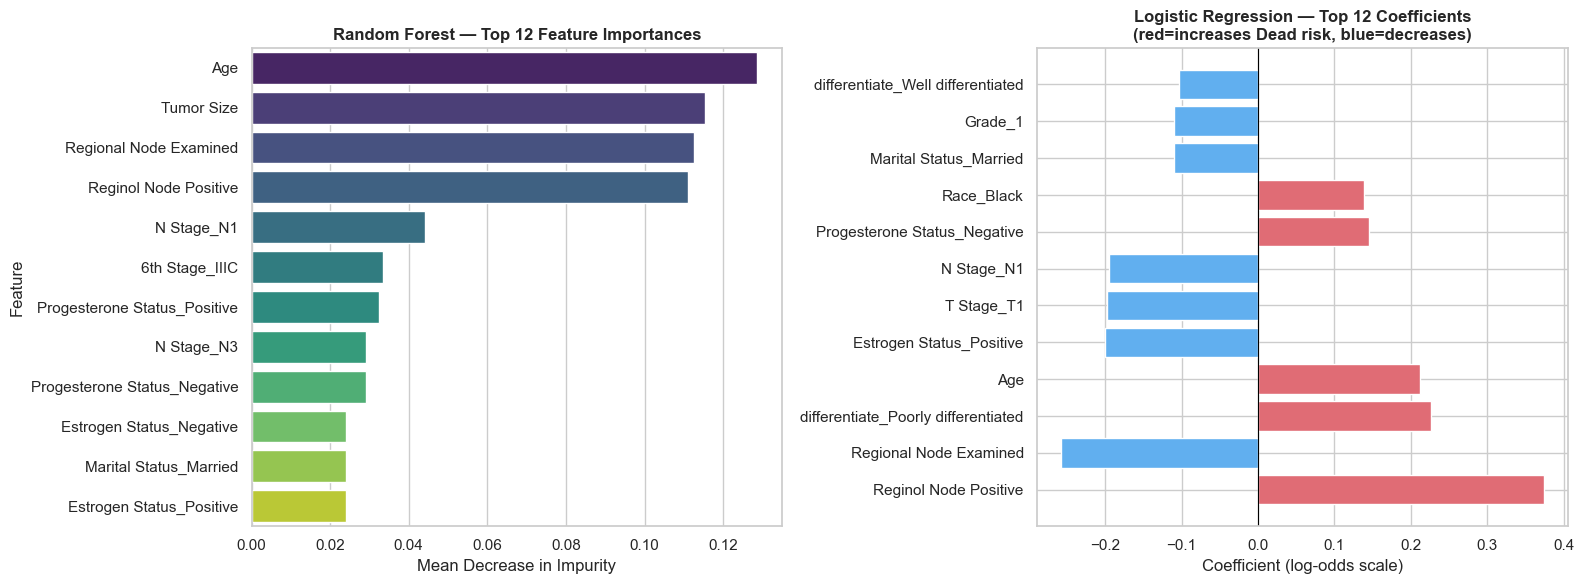

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Random Forest feature importance ---
rf_model = trained_models.get("Random Forest (Tuned)", trained_models["Random Forest (Baseline)"])
if hasattr(rf_model, "feature_importances_"):
    imp_df = pd.DataFrame({
        "Feature"   : feature_columns,
        "Importance": rf_model.feature_importances_
    }).sort_values("Importance", ascending=False).head(12)

    sns.barplot(data=imp_df, x="Importance", y="Feature", palette="viridis", ax=axes[0])
    axes[0].set_title("Random Forest — Top 12 Feature Importances", fontweight="bold")
    axes[0].set_xlabel("Mean Decrease in Impurity")

# --- Logistic Regression coefficients ---
lr_model = trained_models.get("Logistic Regression (Tuned)", trained_models["Logistic Regression"])
coef_df = pd.DataFrame({
    "Feature"    : feature_columns,
    "Coefficient": lr_model.coef_[0]
}).reindex(pd.Series(lr_model.coef_[0]).abs().sort_values(ascending=False).index)
coef_df = coef_df.head(12)

colors_coef = ["#E06C75" if c > 0 else "#61AFEF" for c in coef_df["Coefficient"]]
axes[1].barh(coef_df["Feature"], coef_df["Coefficient"], color=colors_coef)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Logistic Regression — Top 12 Coefficients\n(red=increases Dead risk, blue=decreases)",
                  fontweight="bold")
axes[1].set_xlabel("Coefficient (log-odds scale)")

plt.tight_layout()
plt.show()

---
## 7. Inference on a New Unseen Patient

We construct a **manually defined** patient not present in the dataset and run
it through the same preprocessing pipeline (one-hot encoding + scaling)
before passing it to the selected model.

In [31]:
# --- Define a new unseen patient ---
new_patient_raw = pd.DataFrame([{
    "Age"                   : 52,
    "Race"                  : "White",
    "Marital Status"        : "Married",
    "T Stage"               : "T2",
    "N Stage"               : "N1",
    "6th Stage"             : "IIA",
    "differentiate"         : "Moderately differentiated",
    "Grade"                 : "2",
    "A Stage"               : "Regional",
    "Tumor Size"            : 28,
    "Estrogen Status"       : "Positive",
    "Progesterone Status"   : "Positive",
    "Regional Node Examined": 12,
    "Reginol Node Positive" : 2
}])

# Apply same one-hot encoding: align with training columns
df_full_for_encode = df_model.drop(columns=["Status"]).copy()
new_combined = pd.concat([df_full_for_encode, new_patient_raw], ignore_index=True)
new_combined_enc = pd.get_dummies(new_combined, columns=cat_cols, drop_first=False)
bool_c = new_combined_enc.select_dtypes(include="bool").columns
new_combined_enc[bool_c] = new_combined_enc[bool_c].astype(int)

# Extract the last row (our new patient)
new_patient_enc = new_combined_enc.iloc[[-1]].reindex(columns=feature_columns, fill_value=0)
new_patient_scaled = scaler.transform(new_patient_enc.astype(float))

# Predict
pred_label = best_model.predict(new_patient_scaled)[0]
pred_proba = best_model.predict_proba(new_patient_scaled)[0]

print("=" * 50)
print("New Patient Clinical Profile:")
for col, val in new_patient_raw.iloc[0].items():
    print(f"  {col:<30}: {val}")
print("=" * 50)
print(f"Predicted class : {'Dead' if pred_label == 1 else 'Alive'}")
print(f"P(Alive) = {pred_proba[0]:.4f}  |  P(Dead) = {pred_proba[1]:.4f}")

New Patient Clinical Profile:
  Age                           : 52
  Race                          : White
  Marital Status                : Married
  T Stage                       : T2
  N Stage                       : N1
  6th Stage                     : IIA
  differentiate                 : Moderately differentiated
  Grade                         : 2
  A Stage                       : Regional
  Tumor Size                    : 28
  Estrogen Status               : Positive
  Progesterone Status           : Positive
  Regional Node Examined        : 12
  Reginol Node Positive         : 2
Predicted class : Alive
P(Alive) = 0.7642  |  P(Dead) = 0.2358


---
## 8. Limitations and Future Improvements

**Limitations:**
- The dataset has significant class imbalance (85% Alive / 15% Dead) which limits
  the model's ability to detect the minority class even with balanced weights.
  Techniques such as SMOTE (synthetic oversampling) could further improve minority-class recall.
- One-hot encoding doubles the feature space; with more data, embeddings or target encoding
  could be more efficient for high-cardinality categoricals.
- No external validation cohort is available; results reflect performance on a single
  holdout split and may not generalise to different hospital populations.
- KNN has no intrinsic class-imbalance correction beyond the feature weighting scheme.

**Future improvements:**
1. Apply SMOTE or class-weighted cost-sensitive learning for better minority-class recall.
2. Use repeated stratified k-fold cross-validation for more robust performance estimates.
3. Explore Gradient Boosting (XGBoost/LightGBM) as an additional candidate.
4. Add domain-driven feature engineering (e.g., node ratio = Reginol Node Positive / Regional Node Examined).
5. Calibrate predicted probabilities for clinical decision-support reliability.